In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import requests
import io
from sklearn.model_selection import train_test_split

In [5]:
url = 'https://en.wikipedia.org/wiki/NIFTY_50#Constituents'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

response = requests.get(url, headers=headers)

html_content = io.StringIO(response.text)
tables = pd.read_html(html_content)

In [6]:
nifty50_df = tables[1]

In [7]:
tickers = nifty50_df['Symbol'].astype('str') + '.NS'
tickers_list = tickers.to_list()
raw_data = yf.download(tickers_list, period='5y', interval='1wk')

/tmp/ipykernel_28107/619996752.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers_list, period='5y', interval='1wk')
[*********************100%***********************]  50 of 50 completed


In [8]:
nifty50_index = yf.download('^NSEI', period='5y', interval='1wk')

/tmp/ipykernel_28107/3207207064.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty50_index = yf.download('^NSEI', period='5y', interval='1wk')
[*********************100%***********************]  1 of 1 completed


In [28]:
close_prices = raw_data['Close']
benchmark = nifty50_index['Close']

In [29]:
display(close_prices.isna().sum())
display(benchmark.isna().sum())

,0
Ticker,
ADANIENT.NS,0
ADANIPORTS.NS,0
APOLLOHOSP.NS,0
ASIANPAINT.NS,0
AXISBANK.NS,0
BAJAJ-AUTO.NS,0
BAJAJFINSV.NS,0
BAJFINANCE.NS,0
BEL.NS,0


,0
Ticker,
^NSEI,0


In [30]:
close_prices = close_prices.dropna(axis=1)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(close_prices, benchmark, test_size=0.4, shuffle=False)

In [33]:
log_returns = np.log(X_train/X_train.shift(1)).dropna()

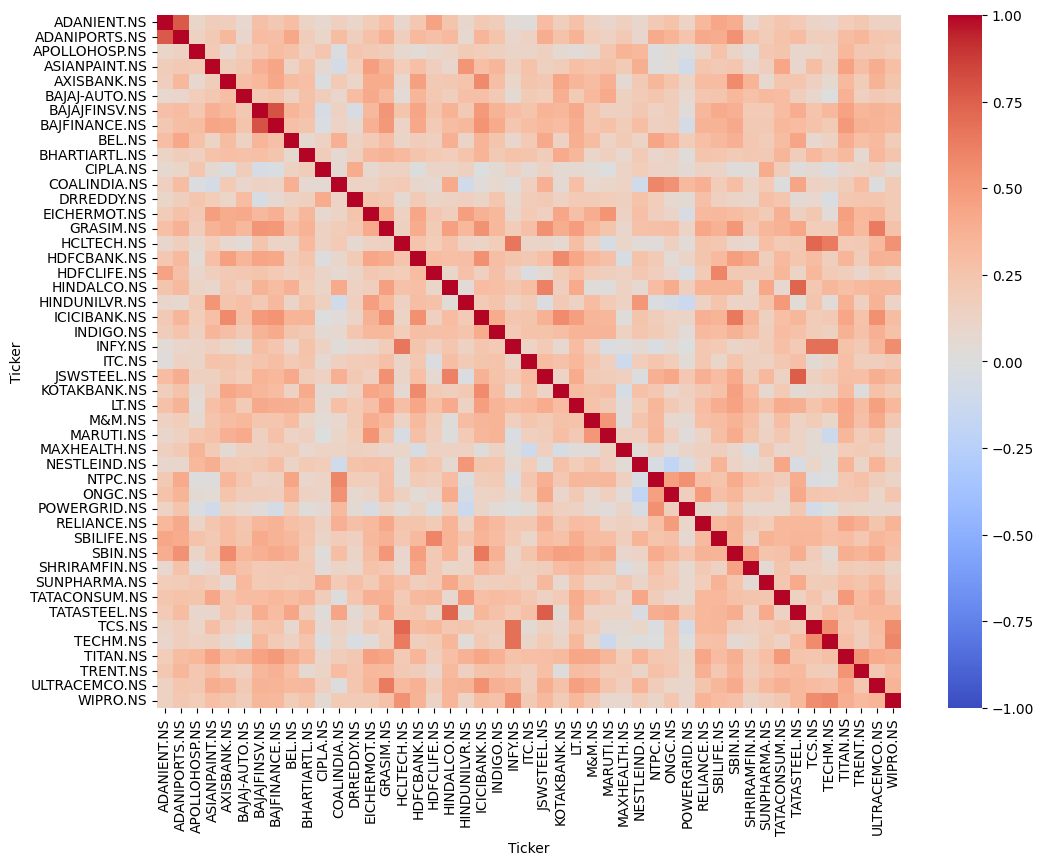

In [34]:
corr_matrix = log_returns.corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [35]:
scaled_log_returns = StandardScaler().fit_transform(log_returns)

pca = PCA(n_components=10)
pca.fit(scaled_log_returns)

PCA(n_components=10)

In [36]:
display(pca.explained_variance_)
display(pca.explained_variance_ratio_)

array([12.42218901,  3.64073718,  3.2816873 ,  2.31637104,  1.8217663 ,
        1.78948803,  1.52388251,  1.25513652,  1.22618262,  1.16741093])

array([0.26259672, 0.07696274, 0.06937266, 0.04896653, 0.03851091,
       0.03782857, 0.03221385, 0.02653274, 0.02592068, 0.02467828])

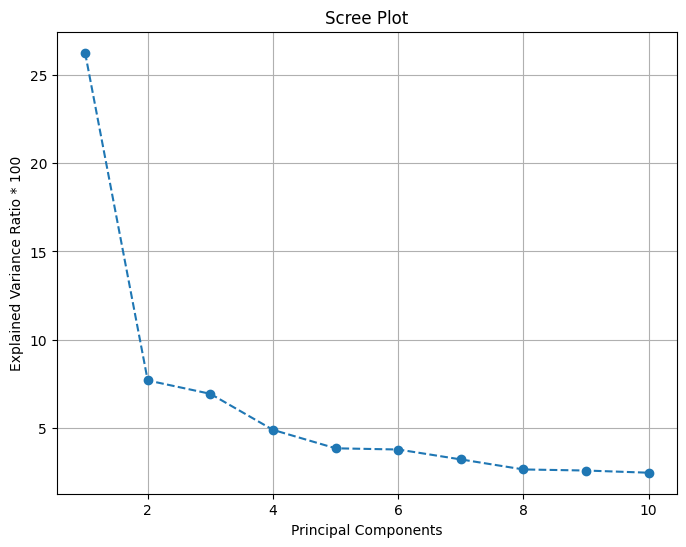

In [37]:
plt.figure(figsize=(8, 6))
plt.plot(range(1,11), pca.explained_variance_ratio_*100, marker='o', linestyle='--')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio * 100')
plt.title('Scree Plot')
plt.grid()
plt.show()

In [38]:
industry_map = (
    nifty50_df[['Symbol', 'Sector[15]']].drop_duplicates('Symbol').set_index('Symbol')['Sector[15]']
)

In [39]:
pc1_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[0] * 100
})

pc1_df['Industry'] = pc1_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc1_sorted = pc1_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc1_sorted.head(10))
display(pc1_sorted.tail(10))

,Ticker,Weight,Industry
14,GRASIM.NS,20.368260,Construction Materials
43,TITAN.NS,19.486721,Consumer Durables
36,SBIN.NS,19.415940,Financial Services
20,ICICIBANK.NS,19.358391,Financial Services
26,LT.NS,18.884208,Construction
7,BAJFINANCE.NS,18.637610,Financial Services
6,BAJAJFINSV.NS,18.483850,Financial Services
45,ULTRACEMCO.NS,18.387823,Construction Materials
35,SBILIFE.NS,17.499180,Financial Services
16,HDFCBANK.NS,17.468221,Financial Services


,Ticker,Weight,Industry
23,ITC.NS,11.678888,Fast Moving Consumer Goods
15,HCLTECH.NS,11.490282,Information Technology
42,TECHM.NS,11.394299,Information Technology
30,NESTLEIND.NS,10.486209,Fast Moving Consumer Goods
11,COALINDIA.NS,10.170629,"Oil, Gas & Consumable Fuels"
12,DRREDDY.NS,9.463591,Healthcare
2,APOLLOHOSP.NS,9.199904,Healthcare
29,MAXHEALTH.NS,6.523086,Healthcare
33,POWERGRID.NS,5.490578,Power
10,CIPLA.NS,5.419224,Healthcare


In [40]:
pc2_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[1] * 100
})

pc2_df['Industry'] = pc2_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc2_sorted = pc2_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc2_sorted.head(10))
display(pc2_sorted.tail(10))

,Ticker,Weight,Industry
11,COALINDIA.NS,32.611540,"Oil, Gas & Consumable Fuels"
32,ONGC.NS,28.662228,"Oil, Gas & Consumable Fuels"
40,TATASTEEL.NS,27.600310,Metals & Mining
31,NTPC.NS,24.882655,Power
24,JSWSTEEL.NS,24.788081,Metals & Mining
18,HINDALCO.NS,24.468245,Metals & Mining
33,POWERGRID.NS,21.442157,Power
8,BEL.NS,15.547418,Capital Goods
1,ADANIPORTS.NS,15.244415,Services
0,ADANIENT.NS,10.384840,Metals & Mining


,Ticker,Weight,Industry
16,HDFCBANK.NS,-10.273815,Financial Services
5,BAJAJ-AUTO.NS,-10.722542,Automobile and Auto Components
27,M&M.NS,-11.484932,Automobile and Auto Components
25,KOTAKBANK.NS,-12.300584,Financial Services
28,MARUTI.NS,-12.370839,Automobile and Auto Components
39,TATACONSUM.NS,-17.267114,Fast Moving Consumer Goods
13,EICHERMOT.NS,-18.933726,Automobile and Auto Components
3,ASIANPAINT.NS,-22.388080,Consumer Durables
30,NESTLEIND.NS,-28.100292,Fast Moving Consumer Goods
19,HINDUNILVR.NS,-29.538856,Fast Moving Consumer Goods


In [41]:
pc3_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[2] * 100
})

pc3_df['Industry'] = pc3_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc3_sorted = pc3_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc3_sorted.head(10))
display(pc3_sorted.tail(10))

,Ticker,Weight,Industry
42,TECHM.NS,39.886521,Information Technology
22,INFY.NS,39.586752,Information Technology
15,HCLTECH.NS,39.326777,Information Technology
41,TCS.NS,36.738584,Information Technology
46,WIPRO.NS,27.006087,Information Technology
9,BHARTIARTL.NS,8.269211,Telecommunication
18,HINDALCO.NS,7.588046,Metals & Mining
38,SUNPHARMA.NS,6.324745,Healthcare
45,ULTRACEMCO.NS,5.361915,Construction Materials
6,BAJAJFINSV.NS,5.121913,Financial Services


,Ticker,Weight,Industry
27,M&M.NS,-10.705148,Automobile and Auto Components
37,SHRIRAMFIN.NS,-10.763464,Financial Services
13,EICHERMOT.NS,-10.950074,Automobile and Auto Components
33,POWERGRID.NS,-12.524487,Power
5,BAJAJ-AUTO.NS,-14.120095,Automobile and Auto Components
25,KOTAKBANK.NS,-14.526768,Financial Services
4,AXISBANK.NS,-15.496705,Financial Services
36,SBIN.NS,-17.715355,Financial Services
31,NTPC.NS,-22.106028,Power
28,MARUTI.NS,-23.262296,Automobile and Auto Components


In [42]:
pc4_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[3] * 100
})

pc4_df['Industry'] = pc4_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc4_sorted = pc4_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc4_sorted.head(10))
display(pc4_sorted.tail(10))

,Ticker,Weight,Industry
10,CIPLA.NS,36.546319,Healthcare
29,MAXHEALTH.NS,32.027958,Healthcare
2,APOLLOHOSP.NS,30.105078,Healthcare
12,DRREDDY.NS,29.894183,Healthcare
38,SUNPHARMA.NS,28.518174,Healthcare
44,TRENT.NS,15.132886,Consumer Services
19,HINDUNILVR.NS,14.753622,Fast Moving Consumer Goods
30,NESTLEIND.NS,14.530406,Fast Moving Consumer Goods
39,TATACONSUM.NS,13.419746,Fast Moving Consumer Goods
3,ASIANPAINT.NS,9.596212,Consumer Durables


,Ticker,Weight,Industry
22,INFY.NS,-8.437966,Information Technology
42,TECHM.NS,-10.260260,Information Technology
26,LT.NS,-11.194117,Construction
6,BAJAJFINSV.NS,-13.320197,Financial Services
36,SBIN.NS,-16.233793,Financial Services
37,SHRIRAMFIN.NS,-19.716685,Financial Services
4,AXISBANK.NS,-20.805225,Financial Services
16,HDFCBANK.NS,-23.816141,Financial Services
25,KOTAKBANK.NS,-24.177163,Financial Services
20,ICICIBANK.NS,-24.936249,Financial Services


### Performance Measurement

In [24]:
# ==============================================================================
# 1. CORE MATH & PORTFOLIO SIMULATION ENGINES
# ==============================================================================
def extract_strategy_weights(pca_model, columns, pc_index, strategy_type='auto'):
    """Extracts and normalizes weights based on the chosen strategy."""
    raw_weights = pca_model.components_[pc_index]
    
    # Auto-detect strategy: PC1 is usually Long-Only, everything else is Long/Short
    if strategy_type == 'auto':
        strategy_type = 'long_only' if pc_index == 0 else 'long_short'
        
    if strategy_type == 'long_only':
        # Fix sign direction for PC1
        if np.sum(raw_weights) < 0:
            raw_weights = -raw_weights
        long_weights = np.maximum(0, raw_weights)
        return pd.Series(long_weights / np.sum(long_weights), index=columns), 'Long-Only'
        
    elif strategy_type == 'long_short':
        # Normalize Longs to +1.0 and Shorts to -1.0 (Dollar Neutral)
        longs = np.maximum(0, raw_weights)
        shorts = np.minimum(0, raw_weights)
        norm_longs = longs / np.sum(longs) if np.sum(longs) > 0 else longs
        norm_shorts = shorts / abs(np.sum(shorts)) if np.sum(shorts) < 0 else shorts
        return pd.Series(norm_longs + norm_shorts, index=columns), 'Long/Short (Market Neutral)'

def simulate_portfolio(price_data, weights, initial_capital, strategy_name):
    """Simulates the portfolio equity curve based on strategy type."""
    initial_prices = price_data.iloc[0]
    shares = (initial_capital * weights) / initial_prices
    
    if strategy_name == 'Long-Only':
        # Portfolio value is just the current value of the shares held
        return price_data.dot(shares)
    else:
        # Long/Short Portfolio: Initial Capital is margin. 
        # PnL = (Current Prices * Shares). Note: Shorts are negative shares, so dropping prices = profit.
        return initial_capital + price_data.dot(shares)

def align_benchmark(benchmark_data, initial_capital):
    """Normalizes the benchmark to start at the exact same capital as the portfolio."""
    if isinstance(benchmark_data, pd.DataFrame):
        benchmark_data = benchmark_data.iloc[:, 0]
    return (benchmark_data / benchmark_data.iloc[0]) * initial_capital

# ==============================================================================
# 2. INSTITUTIONAL METRICS ENGINE
# ==============================================================================
def calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr):
    df = pd.concat([port_val, bench_val], axis=1).dropna()
    df.columns = ['Portfolio', 'Benchmark']
    
    returns = df.pct_change().dropna()
    p_ret, b_ret = returns['Portfolio'], returns['Benchmark']
    
    # CAGR
    ann_p_ret = (df['Portfolio'].iloc[-1] / df['Portfolio'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    ann_b_ret = (df['Benchmark'].iloc[-1] / df['Benchmark'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    
    # Volatility
    ann_p_vol = p_ret.std() * np.sqrt(periods_per_yr)
    ann_b_vol = b_ret.std() * np.sqrt(periods_per_yr)
    
    # Sharpe
    p_sharpe = (ann_p_ret - rf_rate) / ann_p_vol
    b_sharpe = (ann_b_ret - rf_rate) / ann_b_vol
    
    # Sortino
    p_down_dev = np.sqrt(np.mean(np.where(p_ret < 0, p_ret**2, 0))) * np.sqrt(periods_per_yr)
    p_sortino = (ann_p_ret - rf_rate) / p_down_dev if p_down_dev > 0 else np.nan
    b_down_dev = np.sqrt(np.mean(np.where(b_ret < 0, b_ret**2, 0))) * np.sqrt(periods_per_yr)
    b_sortino = (ann_b_ret - rf_rate) / b_down_dev if b_down_dev > 0 else np.nan
    
    # Drawdowns
    p_dd = (df['Portfolio'] - df['Portfolio'].cummax()) / df['Portfolio'].cummax()
    b_dd = (df['Benchmark'] - df['Benchmark'].cummax()) / df['Benchmark'].cummax()
    
    # Beta & Alpha
    cov = np.cov(p_ret, b_ret)
    beta = cov[0, 1] / cov[1, 1]
    alpha = ann_p_ret - (rf_rate + beta * (ann_b_ret - rf_rate))
    
    # Calmar
    p_calmar = ann_p_ret / abs(p_dd.min())
    b_calmar = ann_b_ret / abs(b_dd.min())
    
    metrics = pd.DataFrame({
        'Portfolio': [f"{ann_p_ret*100:.2f}%", f"{ann_p_vol*100:.2f}%", f"{p_sharpe:.2f}", f"{p_sortino:.2f}", f"{p_dd.min()*100:.2f}%", f"{p_calmar:.2f}", f"{beta:.2f}", f"{alpha*100:.2f}%"],
        'Benchmark': [f"{ann_b_ret*100:.2f}%", f"{ann_b_vol*100:.2f}%", f"{b_sharpe:.2f}", f"{b_sortino:.2f}", f"{b_dd.min()*100:.2f}%", f"{b_calmar:.2f}", "1.00", "0.00%"]
    }, index=['Return (CAGR)', 'Volatility', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Calmar Ratio', 'Beta', "Jensen's Alpha"])
    
    return metrics, p_dd, b_dd, p_ret, b_ret

# ==============================================================================
# 3. MASTER WRAPPER & PLOTTING DASHBOARD
# ==============================================================================
def evaluate_pc_strategy(pca_model, pc_index, price_data, benchmark_data, strategy='auto', initial_capital=100000, rf_rate=0.06, periods_per_yr=52):
    """
    The Ultimate Master Function. Put in a PC index, get out the full institutional dashboard.
    """
    # 1. Build Portfolio
    weights, strat_name = extract_strategy_weights(pca_model, price_data.columns, pc_index, strategy)
    port_val = simulate_portfolio(price_data, weights, initial_capital, strat_name)
    bench_val = align_benchmark(benchmark_data, initial_capital)
    
    # 2. Get Metrics
    metrics_df, p_dd, b_dd, p_ret, b_ret = calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr)
    
    # 3. Print Results
    actual_pc = pc_index + 1
    print("\n" + "="*65)
    print(f" 🎯 STRATEGY REPORT: Principal Component {actual_pc} [{strat_name}]")
    print("="*65)
    display(metrics_df)
    
    # 4. Render Dashboard
    fig = plt.figure(figsize=(14, 12))
    gs = fig.add_gridspec(3, 1, height_ratios=[2.5, 1, 1], hspace=0.3)
    
    # Chart 1: Equity Curve
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(port_val.index, (port_val/initial_capital)*100, label=f'PC{actual_pc} Portfolio', color='#1f77b4', linewidth=2.5)
    ax1.plot(bench_val.index, (bench_val/initial_capital)*100, label='Benchmark', color='#4a4a4a', linewidth=1.5, alpha=0.8)
    ax1.set_title(f'Equity Curve (Normalized to 100 Base)', fontsize=14, fontweight='bold', loc='left')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper left')
    
    # Chart 2: Drawdowns
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.fill_between(p_dd.index, p_dd * 100, 0, color='#d62728', alpha=0.3, label='Portfolio Drawdown')
    ax2.plot(b_dd.index, b_dd * 100, color='black', linewidth=1.2, alpha=0.7, label='Benchmark Drawdown')
    ax2.set_title('Underwater Plot (Capital Drawdowns %)', fontsize=12, fontweight='bold', loc='left')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='lower right')
    
    # Chart 3: Rolling Beta
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    rolling_window = max(int(periods_per_yr / 2), 1) # 6-month rolling window
    rolling_beta = p_ret.rolling(window=rolling_window).cov(b_ret) / b_ret.rolling(window=rolling_window).var()
    ax3.plot(rolling_beta.index, rolling_beta, color='#2ca02c', linewidth=2, label=f'Rolling {rolling_window}-Period Beta')
    ax3.axhline(1.0 if strat_name == 'Long-Only' else 0.0, color='black', linestyle='--', alpha=0.5, label='Target Beta')
    ax3.set_title(f'Systemic Risk (Rolling {rolling_window}-Period Beta)', fontsize=12, fontweight='bold', loc='left')
    ax3.grid(True, linestyle='--', alpha=0.5)
    ax3.legend(loc='lower left')
    
    plt.show()




 🎯 STRATEGY REPORT: Principal Component 1 [Long-Only]


,Portfolio,Benchmark
Return (CAGR),9.22%,3.34%
Volatility,14.81%,13.64%
Sharpe Ratio,0.22,-0.19
Sortino Ratio,0.33,-0.28
Max Drawdown,-15.96%,-15.49%
Calmar Ratio,0.58,0.22
Beta,1.06,1.00
Jensen's Alpha,6.03%,0.00%


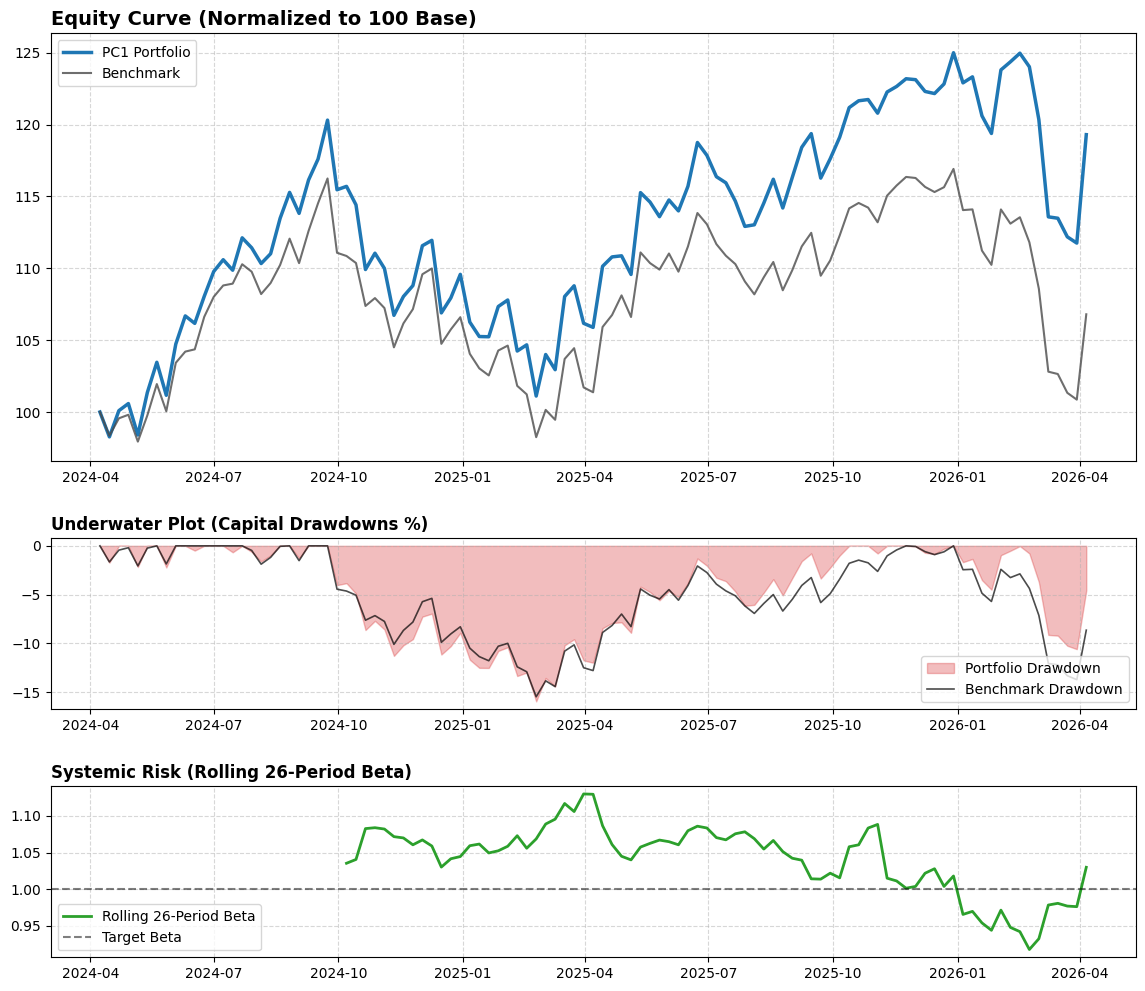

In [43]:
# Test PC1
evaluate_pc_strategy(pca_model=pca, pc_index=0, price_data=X_test, benchmark_data=y_test, periods_per_yr=52)


 🎯 STRATEGY REPORT: Principal Component 2 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),4.29%,3.34%
Volatility,15.60%,13.64%
Sharpe Ratio,-0.11,-0.19
Sortino Ratio,-0.16,-0.28
Max Drawdown,-16.72%,-15.49%
Calmar Ratio,0.26,0.22
Beta,-0.01,1.00
Jensen's Alpha,-1.72%,0.00%


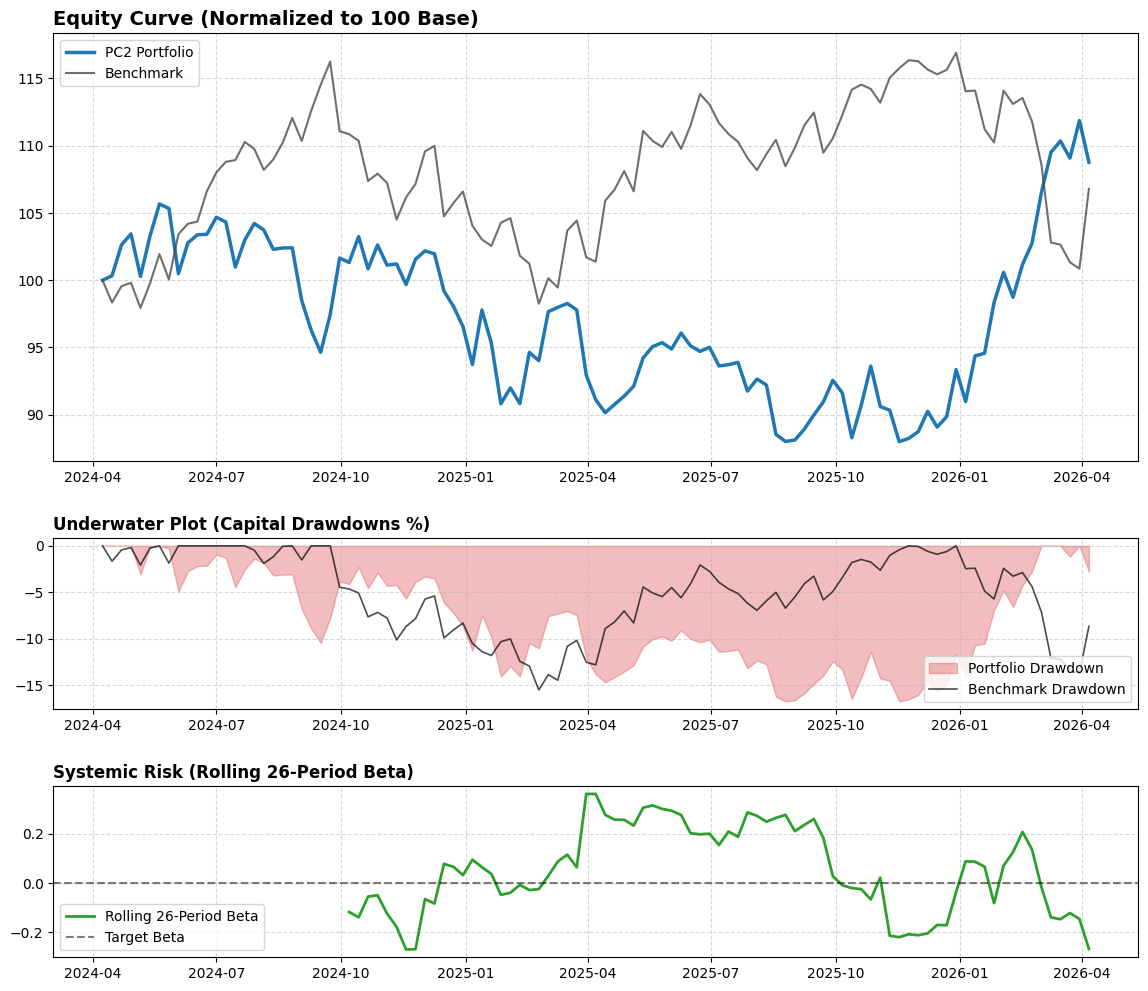

In [44]:
# Test PC2
evaluate_pc_strategy(pca_model=pca, pc_index=1, price_data=X_test, benchmark_data=y_test, periods_per_yr=52)


 🎯 STRATEGY REPORT: Principal Component 3 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),-13.50%,3.34%
Volatility,23.54%,13.64%
Sharpe Ratio,-0.83,-0.19
Sortino Ratio,-1.05,-0.28
Max Drawdown,-43.99%,-15.49%
Calmar Ratio,-0.31,0.22
Beta,-0.42,1.00
Jensen's Alpha,-20.62%,0.00%


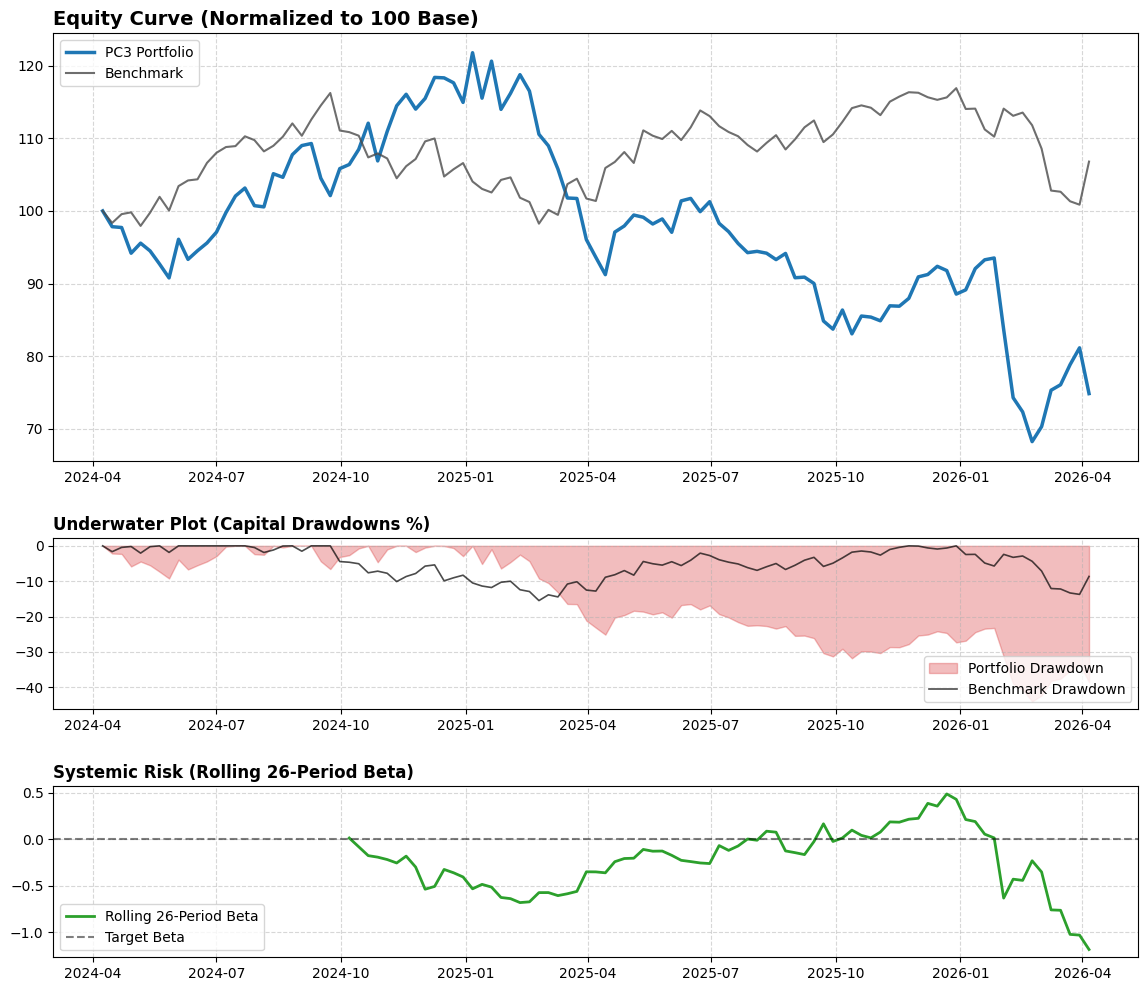

In [45]:
# Test PC3
evaluate_pc_strategy(pca_model=pca, pc_index=2, price_data=X_test, benchmark_data=y_test, periods_per_yr=52)


 🎯 STRATEGY REPORT: Principal Component 4 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),-8.39%,3.34%
Volatility,13.43%,13.64%
Sharpe Ratio,-1.07,-0.19
Sortino Ratio,-1.48,-0.28
Max Drawdown,-25.68%,-15.49%
Calmar Ratio,-0.33,0.22
Beta,-0.25,1.00
Jensen's Alpha,-15.06%,0.00%


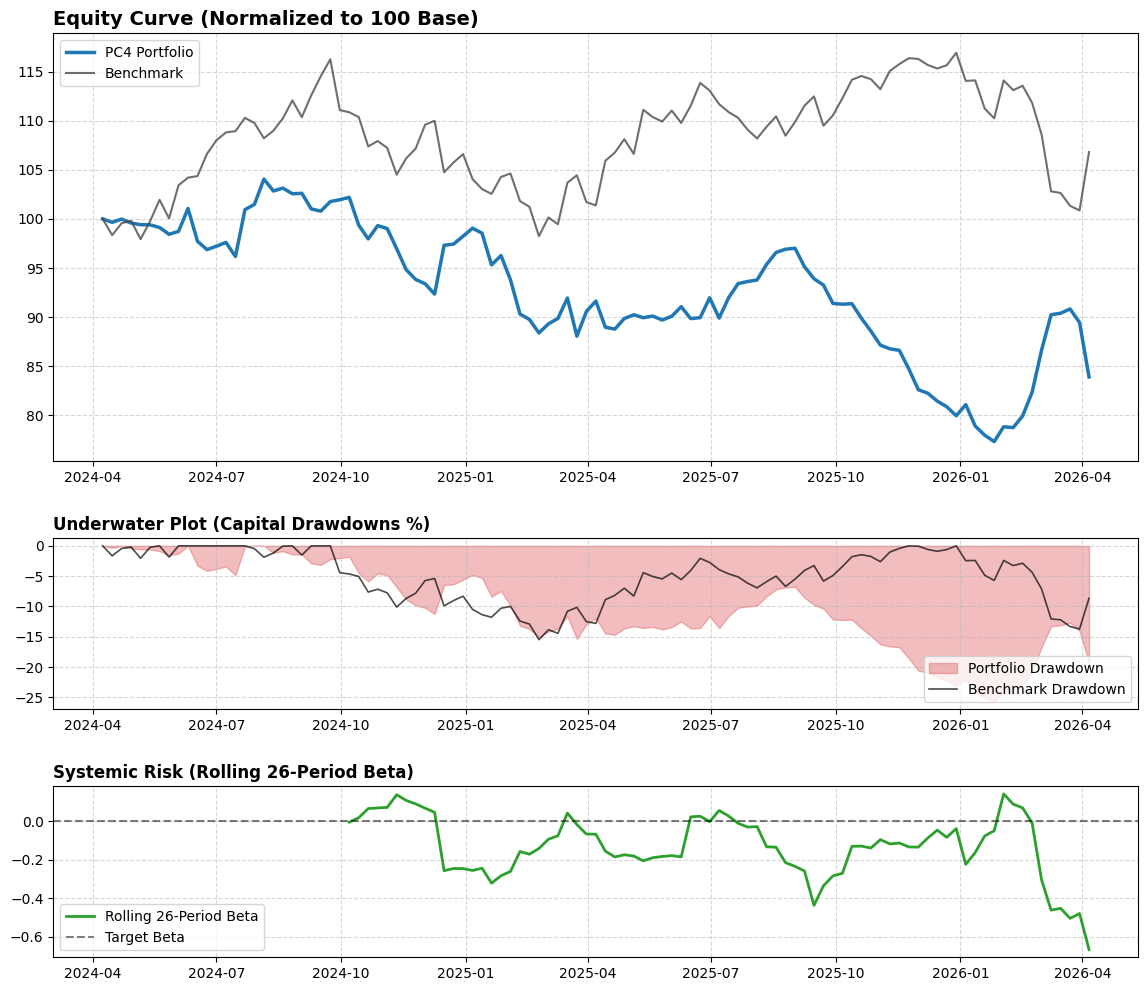

In [46]:
evaluate_pc_strategy(pca_model=pca, pc_index=3, price_data=X_test, benchmark_data=y_test, periods_per_yr=52)